# HOOMD-Blue DPD Force Field: Energy vs Radius

This notebook plots the **Dissipative Particle Dynamics (DPD)** conservative pair potential as implemented in HOOMD-Blue.

## Conservative Potential

The DPD conservative force between two particles is a soft repulsion:

$$F^C(r) = A \left(1 - \frac{r}{r_c}\right), \quad r < r_c$$

Integrating to get the potential energy:

$$U^C(r) = \frac{A}{2} r_c \left(1 - \frac{r}{r_c}\right)^2, \quad r < r_c$$

where:
- $A$ = repulsion amplitude (kT units)
- $r_c$ = cutoff radius
- $r$ = inter-particle separation

Both $F^C$ and $U^C$ are zero for $r \geq r_c$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

## DPD Potential and Force Functions

In [2]:
def dpd_energy(r, A, r_cut):
    """
    HOOMD-Blue DPD conservative pair potential.

    U(r) = (A / 2) * r_cut * (1 - r/r_cut)^2   for r < r_cut
    U(r) = 0                                     for r >= r_cut

    Parameters
    ----------
    r      : array-like, inter-particle distance
    A      : float, repulsion amplitude
    r_cut  : float, cutoff radius

    Returns
    -------
    U : ndarray
    """
    r = np.asarray(r, dtype=float)
    U = np.where(r < r_cut, 0.5 * A * r_cut * (1.0 - r / r_cut)**2, 0.0)
    return U


def dpd_force(r, A, r_cut):
    """
    HOOMD-Blue DPD conservative force magnitude (repulsive).

    F(r) = A * (1 - r/r_cut)   for r < r_cut
    F(r) = 0                   for r >= r_cut
    """
    r = np.asarray(r, dtype=float)
    F = np.where(r < r_cut, A * (1.0 - r / r_cut), 0.0)
    return F

## Plot: Energy & Force vs Radius for Several Amplitudes

/var/folders/jr/8265_v612wxg_7hntt0sy_780000gn/T/ipykernel_86658/3419447773.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


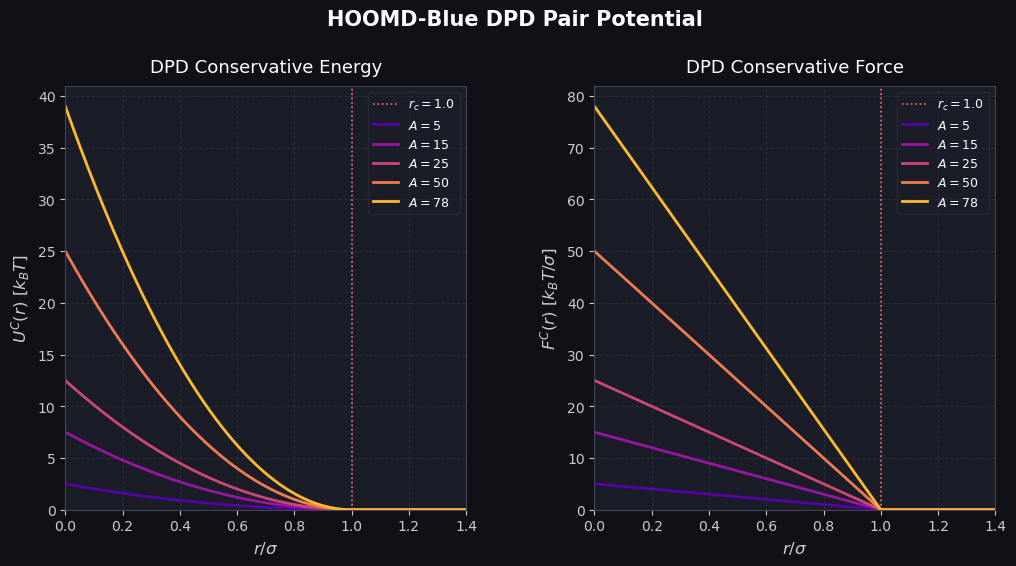

Saved → dpd_energy_force.png


In [3]:
# ── Parameters ──────────────────────────────────────────────────────────────
r_cut = 1.0                        # cutoff radius (HOOMD default = 1.0 σ)
r = np.linspace(0.0, 1.4 * r_cut, 500)

A_values = [5, 15, 25, 50, 78.0]  # typical DPD repulsion amplitudes (kT)
colors    = plt.cm.plasma(np.linspace(0.15, 0.85, len(A_values)))

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 5.5))
fig.patch.set_facecolor('#0f1117')
gs = GridSpec(1, 2, figure=fig, wspace=0.32)
ax_U = fig.add_subplot(gs[0])
ax_F = fig.add_subplot(gs[1])

for ax in (ax_U, ax_F):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#cccccc', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444455')
    ax.grid(True, color='#2a2d3a', linewidth=0.7, linestyle='--')
    ax.axvline(r_cut, color='#ff6b6b', lw=1.2, ls=':', label=f'$r_c = {r_cut}$')

# ── Energy panel ─────────────────────────────────────────────────────────────
for A, c in zip(A_values, colors):
    U = dpd_energy(r, A, r_cut)
    ax_U.plot(r, U, color=c, lw=2.0, label=f'$A = {A:.0f}$')

ax_U.set_xlabel('$r / \\sigma$', color='#cccccc', fontsize=12)
ax_U.set_ylabel('$U^C(r)$ [$k_BT$]', color='#cccccc', fontsize=12)
ax_U.set_title('DPD Conservative Energy', color='white', fontsize=13, pad=10)
ax_U.set_xlim(0, 1.4)
ax_U.set_ylim(bottom=0)
leg_U = ax_U.legend(fontsize=9, framealpha=0.3, labelcolor='white',
                    facecolor='#1a1d27', edgecolor='#444455')

# ── Force panel ──────────────────────────────────────────────────────────────
for A, c in zip(A_values, colors):
    F = dpd_force(r, A, r_cut)
    ax_F.plot(r, F, color=c, lw=2.0, label=f'$A = {A:.0f}$')

ax_F.set_xlabel('$r / \\sigma$', color='#cccccc', fontsize=12)
ax_F.set_ylabel('$F^C(r)$ [$k_BT / \\sigma$]', color='#cccccc', fontsize=12)
ax_F.set_title('DPD Conservative Force', color='white', fontsize=13, pad=10)
ax_F.set_xlim(0, 1.4)
ax_F.set_ylim(bottom=0)
leg_F = ax_F.legend(fontsize=9, framealpha=0.3, labelcolor='white',
                    facecolor='#1a1d27', edgecolor='#444455')

fig.suptitle('HOOMD-Blue DPD Pair Potential', color='white', fontsize=15,
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('dpd_energy_force.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → dpd_energy_force.png')

## Parametric Study: Energy at Contact ($r = 0$) vs $A$

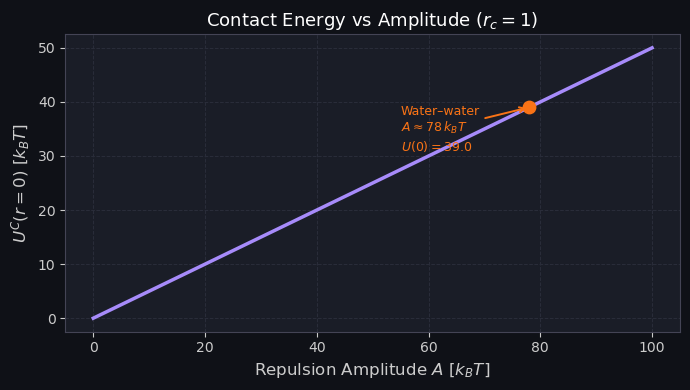

Saved → dpd_contact_energy.png


In [4]:
A_range = np.linspace(0, 100, 300)
U_contact = dpd_energy(0.0, A_range, r_cut)   # U(0) = A * r_cut / 2

fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.patch.set_facecolor('#0f1117')
ax2.set_facecolor('#1a1d27')
ax2.tick_params(colors='#cccccc', labelsize=10)
for spine in ax2.spines.values():
    spine.set_edgecolor('#444455')
ax2.grid(True, color='#2a2d3a', linewidth=0.7, linestyle='--')

ax2.plot(A_range, U_contact, color='#a78bfa', lw=2.5)
ax2.set_xlabel('Repulsion Amplitude $A$ [$k_BT$]', color='#cccccc', fontsize=12)
ax2.set_ylabel('$U^C(r{=}0)$ [$k_BT$]', color='#cccccc', fontsize=12)
ax2.set_title('Contact Energy vs Amplitude ($r_c = 1$)', color='white', fontsize=13)

# annotate water-water value (A ≈ 78 kT at 300 K)
A_water = 78.0
U_water = dpd_energy(0.0, A_water, r_cut)
ax2.scatter([A_water], [U_water], color='#f97316', zorder=5, s=80)
ax2.annotate(f'Water–water\n$A \\approx 78\\,k_BT$\n$U(0) = {U_water:.1f}$',
             xy=(A_water, U_water), xytext=(55, U_water - 8),
             arrowprops=dict(arrowstyle='->', color='#f97316', lw=1.4),
             color='#f97316', fontsize=9)

plt.tight_layout()
plt.savefig('dpd_contact_energy.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Saved → dpd_contact_energy.png')

## Comparison: DPD vs Lennard-Jones at equivalent depth

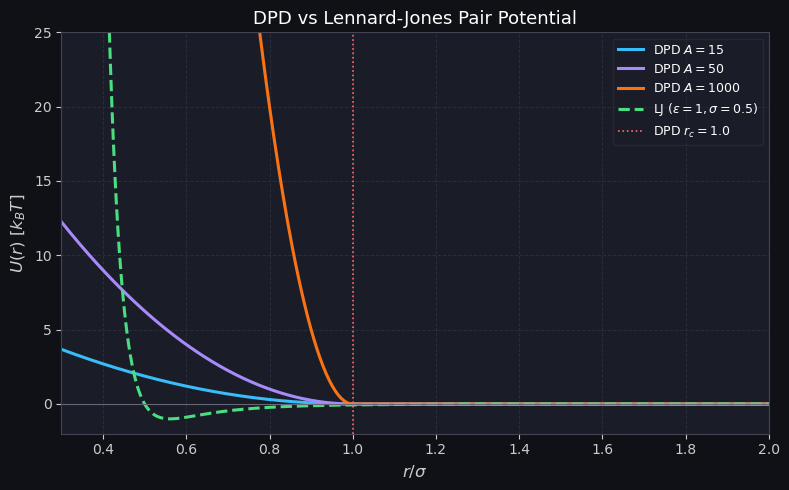

Saved → dpd_vs_lj.png


In [7]:
def lj_energy(r, eps, sigma):
    """Standard 12-6 Lennard-Jones potential (truncated at 2.5σ)."""
    r = np.asarray(r, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        sr6 = np.where(r > 0, (sigma / r)**6, np.inf)
    U = 4 * eps * (sr6**2 - sr6)
    U = np.where(r < 2.5 * sigma, U, 0.0)
    return U

r_compare = np.linspace(0.3, 2.5, 600)

fig3, ax3 = plt.subplots(figsize=(8, 5))
fig3.patch.set_facecolor('#0f1117')
ax3.set_facecolor('#1a1d27')
ax3.tick_params(colors='#cccccc', labelsize=10)
for spine in ax3.spines.values():
    spine.set_edgecolor('#444455')
ax3.grid(True, color='#2a2d3a', linewidth=0.7, linestyle='--')

for A_val, c in zip([15, 50, 1000], ['#38bdf8', '#a78bfa', '#f97316']):
    ax3.plot(r_compare, dpd_energy(r_compare, A_val, r_cut),
             color=c, lw=2.2, label=f'DPD $A={A_val}$')

ax3.plot(r_compare, lj_energy(r_compare, eps=1.0, sigma=0.5),
         color='#4ade80', lw=2.2, ls='--', label='LJ ($\\varepsilon=1, \\sigma=0.5$)')

ax3.set_ylim(-2, 25)
ax3.set_xlim(0.3, 2.0)
ax3.axhline(0, color='#666677', lw=0.8)
ax3.axvline(r_cut, color='#ff6b6b', lw=1.2, ls=':', label=f'DPD $r_c={r_cut}$')
ax3.set_xlabel('$r / \\sigma$', color='#cccccc', fontsize=12)
ax3.set_ylabel('$U(r)$ [$k_BT$]', color='#cccccc', fontsize=12)
ax3.set_title('DPD vs Lennard-Jones Pair Potential', color='white', fontsize=13)
ax3.legend(fontsize=9, framealpha=0.3, labelcolor='white',
           facecolor='#1a1d27', edgecolor='#444455')

plt.tight_layout()
plt.savefig('dpd_vs_lj.png', dpi=150, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.show()
print('Saved → dpd_vs_lj.png')

## Summary Table

In [6]:
print(f"{'A':>8}  {'U(r=0)':>12}  {'F(r=0)':>12}  {'r_eq (F=0)':>12}")
print("-" * 50)
for A in [5, 15, 25, 50, 78]:
    U0 = dpd_energy(0.0, A, r_cut)
    F0 = dpd_force(0.0, A, r_cut)
    print(f"{A:>8}  {U0:>12.3f}  {F0:>12.3f}  {r_cut:>12.3f}")
print()
print("r_eq = r_cut for all A (force vanishes at cutoff, not at a finite minimum)")

       A        U(r=0)        F(r=0)    r_eq (F=0)
--------------------------------------------------
       5         2.500         5.000         1.000
      15         7.500        15.000         1.000
      25        12.500        25.000         1.000
      50        25.000        50.000         1.000
      78        39.000        78.000         1.000

r_eq = r_cut for all A (force vanishes at cutoff, not at a finite minimum)
